<a href="https://colab.research.google.com/github/moralesalessandra29-crypto/LABORATORIO-DE-PDI/blob/main/P7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 7 - Segmentacion Optima**

2055762 Alondra María Cruz Castillo

2063509 Alessandra Morales Vázquez

En esta actividad se realiza la segmentación de una imagen médica utilizando un método sencillo y uno óptimo basado en la conversión de RGB a escala de grises. Se emplea el método SLSQP para obtener coeficientes óptimos de los canales R, G y B que mejoren el contraste. Posteriormente, se elimina el ruido de la imagen segmentada para resaltar el contorno del cráneo y del tumor, y finalmente se calcula el área del tumor como medida de la región de interés.

In [7]:
#LIBRERIAS
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

En esta parte del código se carga la imagen y se realiza la separación de sus canales de color RGB. Como resultado, se observa la imagen original junto con sus componentes rojo, verde y azul por separado.

Mounted at /content/drive


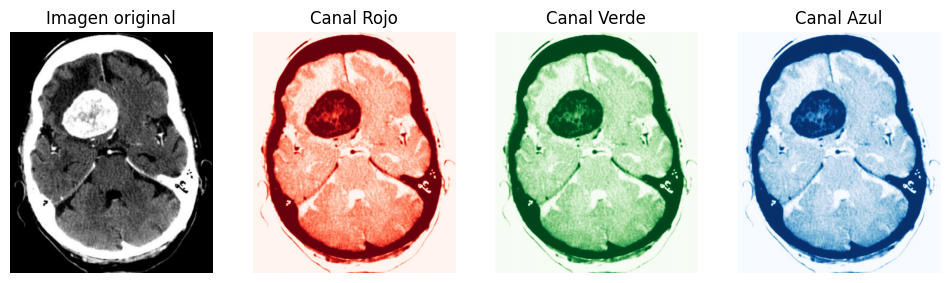

In [2]:
from google.colab import drive
drive.mount('/content/drive')

#CARGAR IMAGEN
ruta = "/content/drive/MyDrive/PDI/tumor.jpg"
img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#SEPARAR CANALES
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

#MOSTRAR CANALES
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(R, cmap='Reds')
plt.title('Canal Rojo')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(G, cmap='Greens')
plt.title('Canal Verde')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(B, cmap='Blues')
plt.title('Canal Azul')
plt.axis('off')
plt.show()



En esta sección se convierte la imagen a escala de grises mediante el promedio de los canales RGB. Como resultado, se obtiene una imagen en tonos de gris que simplifica la información visual.

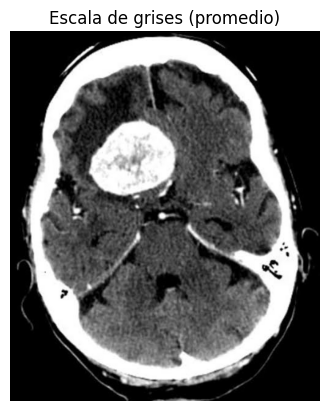

In [3]:
# Convertir a escala de grises promediando canales
gray_avg = ((R.astype(np.float32) + G + B) / 3).astype(np.uint8)

# Mostrar imagen en escala de grises
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises (promedio)')
plt.axis('off')
plt.show()

En esta etapa se aplica una segmentación binaria utilizando un umbral fijo sobre la imagen en escala de grises. Como resultado, la imagen se divide en dos regiones: las zonas con intensidad mayor al umbral se muestran en blanco y las menores en negro.

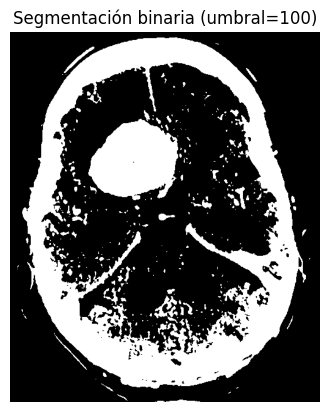

In [4]:
# Umbral para segmentación
umbral = 100
_, segmentada = cv2.threshold(gray_avg, umbral, 255, cv2.THRESH_BINARY)

# Mostrar imagen segmentada
plt.imshow(segmentada, cmap='gray')
plt.title(f'Segmentación binaria (umbral={umbral})')
plt.axis('off')
plt.show()


En esta sección se aplica un proceso de optimización utilizando el método SLSQP para determinar los coeficientes óptimos de los canales R, G y B en la conversión a escala de grises. Como resultado, se obtiene una imagen con mayor contraste en comparación con el método de promedio.

Pesos óptimos: [0.33 0.33 0.34]


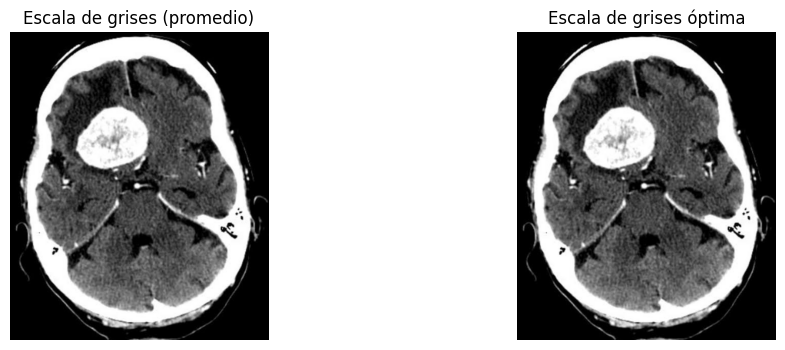

In [8]:
# BGR A RGB
ruta = "/content/drive/MyDrive/PDI/tumor.jpg"
img = cv2.imread(ruta)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# SEPARAR CANALES
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

# NORMALIZACION
R_norm = R.astype(np.float32) / 255
G_norm = G.astype(np.float32) / 255
B_norm = B.astype(np.float32) / 255

# FUNCION OBJETIVO
def grayscale_variance(weights):
    w_r, w_g, w_b = weights
    gray = w_r * R_norm + w_g * G_norm + w_b * B_norm
    gray_normalized = (gray - gray.min()) / (gray.max() - gray.min())
    return -np.var(gray_normalized)

# RESTRICCIONES
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = [(0,1), (0,1), (0,1)]

# OPTIMIZACION
initial_weights = [0.33, 0.33, 0.34]
result = minimize(grayscale_variance, initial_weights, method='SLSQP',
                  bounds=bounds, constraints=constraints)

optimal_weights = result.x
print("Pesos óptimos:", optimal_weights)

# IMAGEN OPTIMA
gray_optimal = (optimal_weights[0]*R_norm +
                optimal_weights[1]*G_norm +
                optimal_weights[2]*B_norm)

gray_optimal = (gray_optimal * 255).astype(np.uint8)

# MOSTRAR RESULTADOS
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(gray_avg, cmap='gray')
plt.title('Escala de grises (promedio)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gray_optimal, cmap='gray')
plt.title('Escala de grises óptima')
plt.axis('off')

plt.show()

En esta sección se aplica una segmentación binaria tanto a la imagen en escala de grises obtenida por promedio como a la imagen optimizada. Como resultado, ambas imágenes quedan divididas en regiones de interés y fondo.

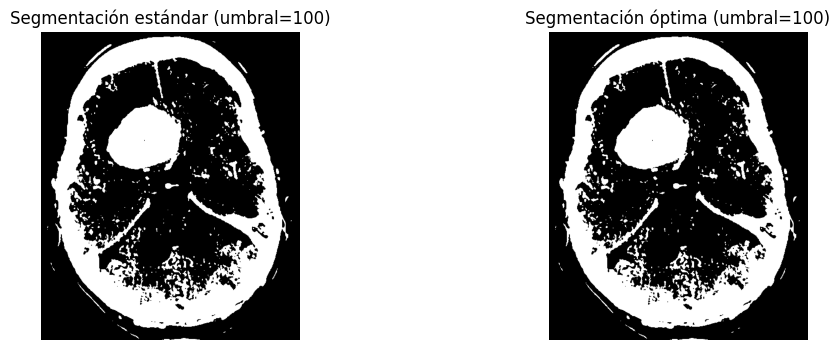

In [9]:
#SEGMENTACION DE LA IMAGENES
umbral = 100
_, seg_standard = cv2.threshold(gray_avg, umbral, 255, cv2.THRESH_BINARY)
_, seg_optimal = cv2.threshold(gray_optimal, umbral, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(seg_standard, cmap='gray')
plt.title(f'Segmentación estándar (umbral={umbral})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(seg_optimal, cmap='gray')
plt.title(f'Segmentación óptima (umbral={umbral})')
plt.axis('off')
plt.show()

En esta etapa se aplican operaciones morfológicas para eliminar el ruido de la imagen segmentada. Primero se utiliza una apertura para remover pequeños objetos o imperfecciones, y posteriormente un cierre para rellenar huecos dentro de las regiones detectadas. Como resultado, se obtiene una imagen más limpia y definida.

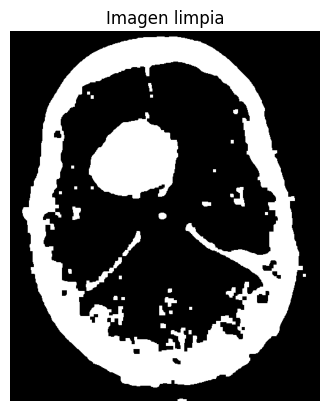

In [10]:
#QUITAR EL RUIDO
kernel = np.ones((5,5), np.uint8)
limpia = cv2.morphologyEx(seg_optimal, cv2.MORPH_OPEN, kernel)
#LLENAR HUECOS
limpia = cv2.morphologyEx(limpia, cv2.MORPH_CLOSE, kernel)

plt.imshow(limpia, cmap='gray')
plt.title('Imagen limpia')
plt.axis('off')
plt.show()

En esta sección se detectan los contornos a partir de la imagen previamente limpiada. Posteriormente, estos contornos se dibujan sobre la imagen original, permitiendo visualizar claramente las regiones detectadas.

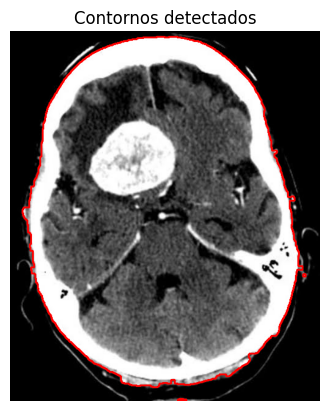

In [11]:
#CONTORNOS
contornos, _ = cv2.findContours(limpia, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contornos = img_rgb.copy()
cv2.drawContours(img_contornos, contornos, -1, (255, 0, 0), 2)

plt.imshow(img_contornos)
plt.title('Contornos detectados')
plt.axis('off')
plt.show()

En esta etapa se calcula el área de los contornos detectados para identificar la región correspondiente al tumor. Se selecciona el contorno con mayor área y se obtiene su tamaño en número de píxeles.

In [12]:
#AREA
areas = [cv2.contourArea(c) for c in contornos]

contorno_tumor = contornos[np.argmax(areas)]

#AREA DEL TUMOR
area_tumor = cv2.contourArea(contorno_tumor)

print("Área del tumor (en píxeles):", area_tumor)

Área del tumor (en píxeles): 200476.0
